In [ ]:
!pip install catboost

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_log_error
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

In [ ]:
train = pd.read_csv('train.txt')
test = pd.read_csv('test.txt')

In [ ]:
def engineer_features(df, is_test=False):
    df = df.copy()

    df['data'] = pd.to_datetime(df['data'])

    df['day_of_week'] = df['data'].dt.dayofweek
    df['day_of_month'] = df['data'].dt.day
    df['month'] = df['data'].dt.month
    df['year'] = df['data'].dt.year
    df['week_of_year'] = df['data'].dt.isocalendar().week
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_month_start'] = (df['day_of_month'] <= 5).astype(int)
    df['is_month_end'] = (df['day_of_month'] >= 25).astype(int)
    df['is_thursday'] = (df["day_of_week"] == 3).astype(int)

    df['season'] = df['month'].apply(lambda x:
        1 if x in [12, 1, 2] else
        2 if x in [3, 4, 5] else
        3 if x in [6, 7, 8] else 4)

    # Academic calendar features (Polish academic year)
    # Semester 1: October-February, Semester 2: February-June
    # Summer break: July-September, Winter break: parts of January-February
    df['is_summer_break'] = df['month'].isin([7, 8, 9]).astype(int)
    df['is_exam_period'] = df['month'].isin([1, 2, 6]).astype(int)
    df['is_semester_active'] = df['month'].isin([10, 11, 12, 3, 4, 5]).astype(int)

    # Boolean conversions
    df['swięto'] = df['święto'].map({'True': 1, 'False': 0, True: 1, False: 0})
    df['dzień_roboczy'] = df['dzień_roboczy'].map({'True': 1, 'False': 0, True: 1, False: 0})

    # Encode weather
    le_weather = LabelEncoder()
    df['pogoda_encoded'] = le_weather.fit_transform(df['pogoda'])

    # Weather feature engineering
    df['is_good_weather'] = df['pogoda'].isin(['ładna_pogoda', 'ładna_pogoda']).astype(int)
    df['is_bad_weather'] = df['pogoda'].isin(['lekkie_opady']).astype(int)

    # Temperature features
    df['temp_feels_like_diff'] = df['temperatura'] - df['odczuwalna_temperatura']
    df['is_cold'] = (df['temperatura'] < 5).astype(int)
    df['is_hot'] = (df['temperatura'] > 25).astype(int)
    df['is_comfortable'] = ((df['temperatura'] >= 15) & (df['temperatura'] <= 25)).astype(int)

    # Wind features
    df['is_windy'] = (df['prędkość_wiatru'] > 20).astype(int)

    # Combined features
    df['good_day_to_go_out'] = (
        (df['is_good_weather'] == 1) &
        (df['is_comfortable'] == 1) &
        (df['is_windy'] == 0)
    ).astype(int)

    df['bad_day'] = (
        (df['is_bad_weather'] == 1) |
        (df['is_cold'] == 1) |
        (df['is_windy'] == 1)
    ).astype(int)

    # Holiday and workday combinations
    df['holiday_weekend'] = (df['swięto'] & df['is_weekend']).astype(int)
    df['workday_weekday'] = (df['dzień_roboczy'] & ~df['is_weekend'].astype(bool)).astype(int)

    return df

In [ ]:
train_processed = engineer_features(train, is_test=False)
test_processed = engineer_features(test, is_test=True)

feature_cols = [
    'month',
    'is_weekend', 'is_thursday', 'season',
    'is_summer_break', 'is_exam_period', 'is_semester_active',
    'swięto', 'dzień_roboczy', 'pogoda_encoded',
    'is_good_weather', 'is_bad_weather',
    'temperatura', 'odczuwalna_temperatura', 'temp_feels_like_diff',
    'wilgotność', 'prędkość_wiatru',
    'is_cold', 'is_hot', 'is_comfortable', 'is_windy',
    'good_day_to_go_out', 'bad_day', 'holiday_weekend', 'workday_weekday'
]

X = train_processed[feature_cols]
y = train_processed['studenty_ms']
X_test = test_processed[feature_cols]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=6969420)


Training data shape: (485, 10)
Test data shape: (243, 9)

Target statistics:
count     485.000000
mean       64.752577
std       193.146437
min         0.000000
25%        15.000000
50%        25.000000
75%        47.000000
max      3098.000000
Name: studenty_ms, dtype: float64


Data plotting

--- EDA Suite for Target: studenty_ms ---


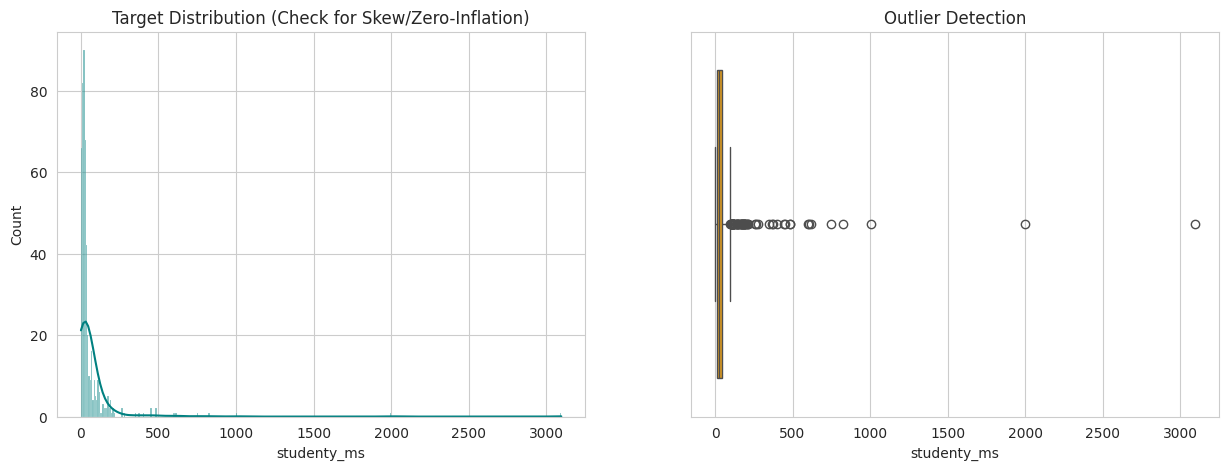

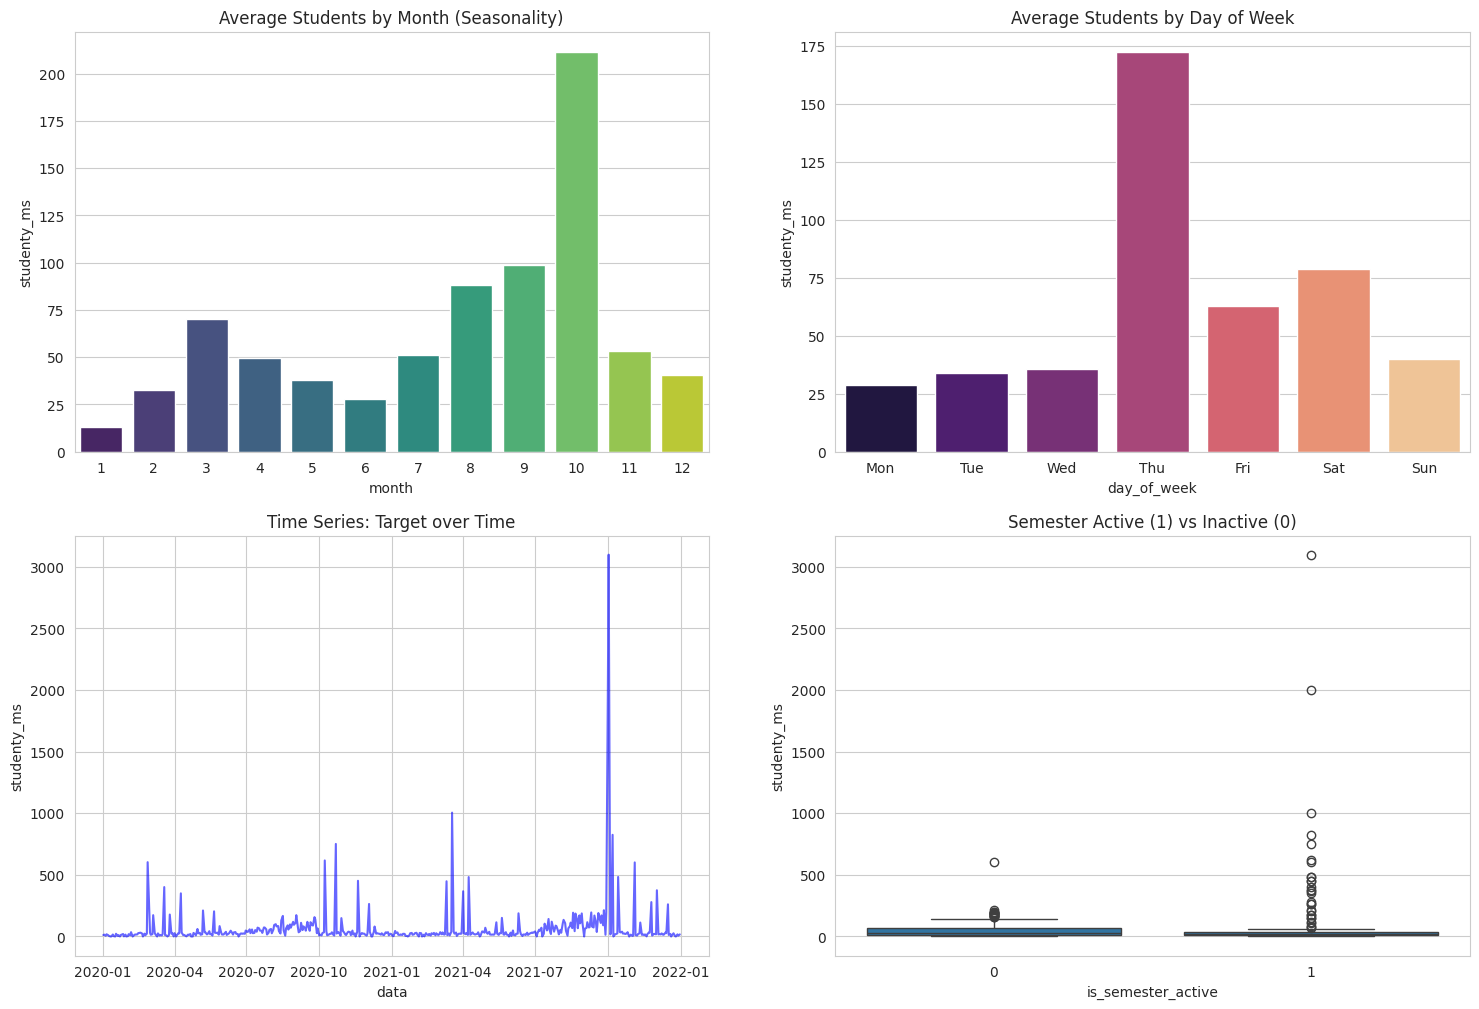

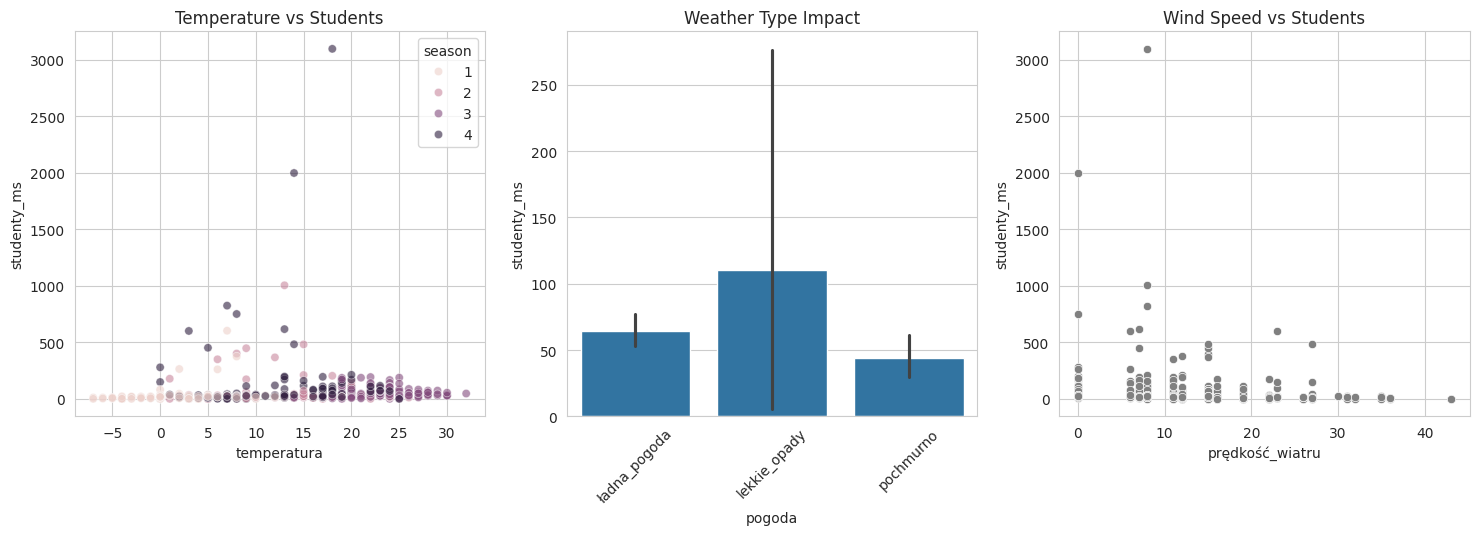

--- Train vs Test Feature Drift ---


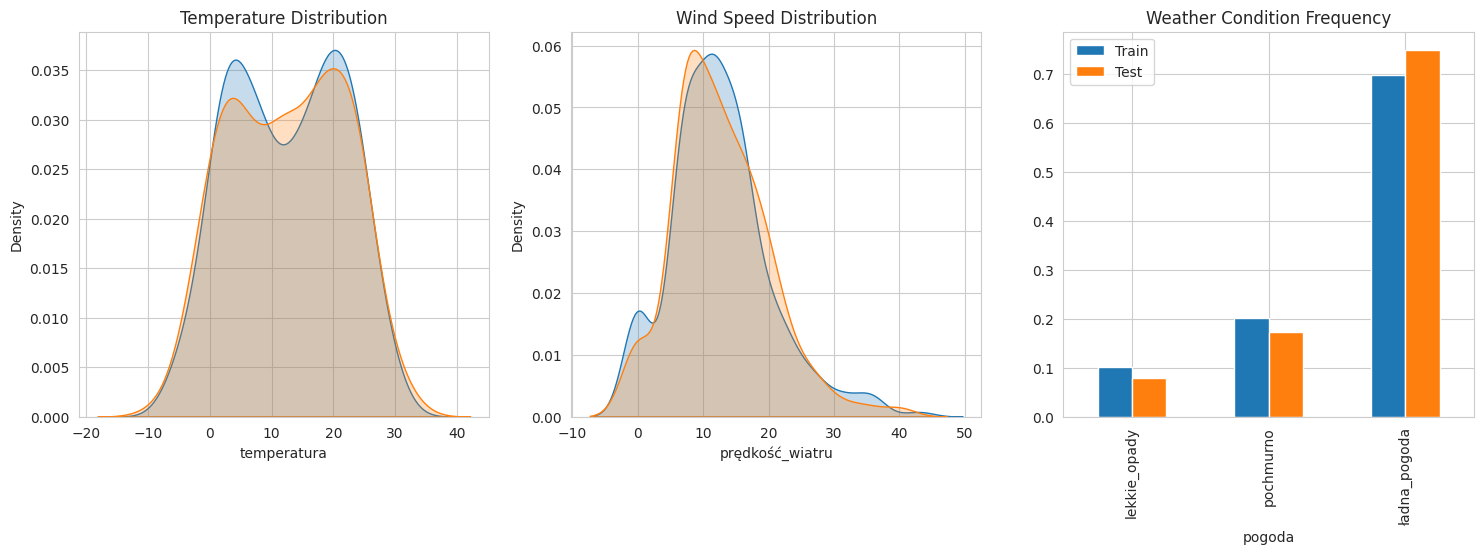

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

def run_eda_suite(train_df, test_df, target_col='studenty_ms'):
    print(f"--- EDA Suite for Target: {target_col} ---")
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(train_df[target_col], kde=True, ax=ax[0], color='teal')
    ax[0].set_title('Target Distribution (Check for Skew/Zero-Inflation)')
    sns.boxplot(x=train_df[target_col], ax=ax[1], color='orange')
    ax[1].set_title('Outlier Detection')
    plt.show()
    fig, ax = plt.subplots(2, 2, figsize=(18, 12))

    sns.barplot(data=train_df, x='month', y=target_col, ax=ax[0,0], palette='viridis', errorbar=None)
    ax[0,0].set_title('Average Students by Month (Seasonality)')

    sns.barplot(data=train_df, x='day_of_week', y=target_col, ax=ax[0,1], palette='magma', errorbar=None)
    ax[0,1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    ax[0,1].set_title('Average Students by Day of Week')

    sns.lineplot(data=train_df, x='data', y=target_col, ax=ax[1,0], color='blue', alpha=0.6)
    ax[1,0].set_title('Time Series: Target over Time')

    sns.boxplot(data=train_df, x='is_semester_active', y=target_col, ax=ax[1,1])
    ax[1,1].set_title('Semester Active (1) vs Inactive (0)')
    plt.show()

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    sns.scatterplot(data=train_df, x='temperatura', y=target_col, hue='season', ax=ax[0], alpha=0.6)
    ax[0].set_title('Temperature vs Students')

    sns.barplot(data=train_df, x='pogoda', y=target_col, ax=ax[1])
    ax[1].tick_params(axis='x', rotation=45)
    ax[1].set_title('Weather Type Impact')

    sns.scatterplot(data=train_df, x='prędkość_wiatru', y=target_col, ax=ax[2], color='gray')
    ax[2].set_title('Wind Speed vs Students')
    plt.show()

    print("--- Train vs Test Feature Drift ---")
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    sns.kdeplot(train_df['temperatura'], label='Train', ax=ax[0], fill=True)
    sns.kdeplot(test_df['temperatura'], label='Test', ax=ax[0], fill=True)
    ax[0].set_title('Temperature Distribution')

    sns.kdeplot(train_df['prędkość_wiatru'], label='Train', ax=ax[1], fill=True)
    sns.kdeplot(test_df['prędkość_wiatru'], label='Test', ax=ax[1], fill=True)
    ax[1].set_title('Wind Speed Distribution')

    train_counts = train_df['pogoda'].value_counts(normalize=True).sort_index()
    test_counts = test_df['pogoda'].value_counts(normalize=True).sort_index()

    df_compare = pd.DataFrame({'Train': train_counts, 'Test': test_counts})
    df_compare.plot(kind='bar', ax=ax[2])
    ax[2].set_title('Weather Condition Frequency')
    plt.show()
    
run_eda_suite(train_processed, test_processed)